# Run the RTTOV Notebook

This notebook offers a quick-start test for running RTTOV on a single AROME‑Austria time step. It is adapted from `visir_run_main.py` and generates visible‑channel reflectances.  
It also includes utility functions for loading results and plotting key variables.

## Environment Setup (JupyterHub)

Follow these steps on `jupyterhub.ecmwf.int` to create a Python 3.8.8 environment compatible with the RTTOV‑Python interface.

**SSH Access**  
Ensure your SSH keys are configured for `jupyterhub.ecmwf.int` (see ECMWF documentation).

1. **Load Python 3.8.8**  
   ```bash
   module load python3/3.8.8-01
   ```

2. **Create a Virtual Environment**  
   ```bash
   mkdir -p $PERM/venvs
   cd $PERM/venvs
   python3 -m venv --system-site-packages venv_38
   ```

3. **Activate & Install Dependencies**  
   ```bash
   source $PERM/venvs/venv_38/bin/activate
   pip install pysolar
   ```

4. **Register as a Jupyter Kernel**  
   ```bash
   python3 -m ipykernel install \
     --user \
     --name venv_38 \
     --display-name "Python 3.8 (venv_38)" \
     --env PATH="$PERM/venvs/venv_38/bin:$PATH"
   ```

This creates a kernel named **Python 3.8 (venv_38)** preloaded with the system‑site packages and any additional libraries you install.


### Warning
 
* Using the smallest size of server for the jupyter notebook (8GB) leads to a crash with no explenation, 16 GB is sufficient for it to run.

## Import libraries

In [2]:
import pygrib
import sys
from vis_rttov_arome import *
from visir_profiles_arome import *
from visir_rttov_switches import *

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from datetime import date
from datetime import datetime

## Settings 

In [19]:
"""
Input configuration for visible reflectance simulation

Attributes:
    output_path (str): Full path for the output NetCDF file.
        e.g., '/ec/res4/scratch/km4c/TMP/20250523_debug.nc'
    repo_path (str): Root directory of the cloned RTTOV_AROME repository.
    time_config (dict): Simulation date and time:
        - year (int)
        - month (int)
        - day (int)
        - hour (int)
    channel (str): Spectral channel to simulate; currently only 'visible' is supported.
    settings (dict): RTTOV operation switches and parameters:
        - snow2ice (int)
        - lwc (int)
        - NC (float)            # cloud droplet concentration (cm⁻³)
        - clw_scheme (int)
        - fixed_time (optional)
        - cte_hour (optional)
    experiment_name (str): Identifier for this run.
    experiment_purpose (str): Brief description of the experiment’s goal.
    log_path (str): Path to the log file (currently unused).
"""

# Output configuration
output_path = '/ec/res4/scratch/km4c/20250523_debug.nc'
repo_path     = '/perm/km4c/'

# Simulation date/time
time_config = {
    "year":  2023,
    "month": 8,
    "day":   29,
    "hour":  12,
}

# Channel selection
channel = 'visible'

# RTTOV settings
settings = {
    "snow2ice":   0,
    "lwc":        1,
    "NC":         2.0e8,
    "clw_scheme": 2,
    "fixed_time": None,
    "cte_hour":   None,
}

# Experiment metadata
experiment_name    = 'Debug'
experiment_purpose = 'Test modified vis_rttov_arome.py workflow'
log_path           = '/perm/km4c/log/log.txt'

# Path to forecast data
in_path = "/hpcperm/km4c/arome_forecasts/august23"

## Run RTTOV

In [13]:
def run_main_single(dict_time,in_path, name, purpose, date_executed, channel_spectrum,path_log,output_name,settings_dict, 
                    output_root, rttov_op="v122"):
     """
        Modified version of run_main that gets rid of the looping over multiple timesteps. The output is saved as a netcdf in output_name

        dict_time                     : dictionary containing the year, month, day, and hour to run RTTOV for
        name, purpose, date_executed  : strings that are added to the log (currently disabled)
        channel_spectrum              : string to flip between visible and infrared, but for now it has to be visible
        path_log                      : path to where the log is written into 
        output_name                   : Name of file (with path) where the output is to be stored
     """
     # log_experiment(name, purpose,date_executed,path_log) #Logging disabled for now
     print("Running experiment for the selected time")
 
     #Setting the file paths to read in the data for the selected day and time
     integer_day = dict_time['day']
     grb_path =  f"{in_path}/day_{integer_day:02}/"
     grb_file =  grb_path+f"202308{integer_day:02}_09_0003.grb" 
     
     #Reading the AROME data and verifying that the dates match
     grb = pygrib.open(grb_file)
     target_datetime = datetime(dict_time["year"], dict_time["month"], dict_time["day"], dict_time["hour"], 0, 0)
     validate_grb_datetime([grb],target_datetime)
     configuration = sim_setup_visible(name, rttov_op, settings_dict)
    
     #Calling run_rttov, where the RTTOV settings are set and all the heavy lifting coccurs
     index = 0 #This is left over from how I looped over things, needs to be set to 0 for a single experiment. This looping is also the reason grb is passed as [grb]
     Success_run = run_rttov([grb], index, target_datetime, configuration, True, channel_spectrum, settings_dict,
                             repo_path=repo_path,specific_output_name=output_name, output_root=None)

     print("The experiments are finished!")

In [20]:
# Running RTTOV (this may take a few minutes)

# To switch versions:
#   rttov_op = "v132"  # RTTOV v13.2
#   rttov_op = "v122"  # RTTOV v12.2

run_main_single(
    time_config,
    in_path,
    experiment_name,
    experiment_purpose,
    datetime.now(),
    channel,
    log_path,
    output_path, 
    settings,
    output_root=None,
    rttov_op= "v122"
)

Running experiment for the selected time
1
Date-time validation   
The date and time 2023-08-29 12:00:00 are valid
Date-time validation is done
The user is running RTTOV operator v12.2.


Load successful >>>>> inst_id : 2, nchannels : 1.


get_modelstate - Reading the GRIB files
get_modelstate - GRIB files successfully read
Model data gathered:---------------------------
Temperature K (90, 421, 589)
Model data gathered:---------------------------
surface_temp K (1, 421, 589)
Model data gathered:---------------------------
2 metre temperature K (1, 421, 589)
Model data gathered:---------------------------
Specific humidity kg kg**-1 (90, 421, 589)
Model data gathered:---------------------------
10 metre U wind component m s**-1 (1, 421, 589)
Model data gathered:---------------------------
10 metre V wind component m s**-1 (1, 421, 589)
Model data gathered:---------------------------
Surface pressure hPa (1, 421, 589)
Model data gathered:---------------------------
Pressure hPa (90, 421, 589)
Model data gathered:---------------------------
Liquid Water Kg / Kg (90, 421, 589)
Model data gathered:---------------------------
Cloud Ice Kg / Kg (90, 421, 589)
Model data gathered:---------------------------
Graupol Kg / Kg (90, 

IR emissivity atlas loaded successfully
BRDF atlas loaded successfully


loading brdf atlas...
<BENCHMARK> loading BRDF atlas took 0.711 sec
included in BRDF: sea land seaice
negative albedo values: 247969 of 247969
calling getEmisBrdf...
<BENCHMARK> getting albedo/emissivity took 2.467 sec
albedo histogram:  (array([21125, 40211, 90695, 64902, 25467,  4831,   509,    83,    31,
          16,    12,     0,    27,    16,    14,     0,    15,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0]), array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 ]))
negative albedo values: 15 of 247969
(15 over land, 0 over sea)
negative albedo values: 0 of 247969
(0 over land, 0 over sea)
setting sea albedo values to -1 --> will be replaced by sea brdf model values...
negative albedo values: 20952 of 247969
Calling runDirect on RTTOV object...
negative albedo values: 0 of

Deallocating this inst_id.
Atlas deallocated.
Atlas deallocated.


## Reading and plotting

Currently the synthetic reflectance is saved on the observation grid, not the model grid.

In [23]:
first_exp = xr.load_dataset(output_path)

/home/km4c/.local/lib/python3.8/site-packages/xarray/backends/plugins.py:71: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


In [24]:
first_exp

<xarray.Dataset>
Dimensions:                       (lat_obs: 220, lon_obs: 520,
                                   sky_condition: 2, dim1: 421, dim2: 589, k: 1)
Coordinates:
  * dim1                          (dim1) int64 0 1 2 3 4 ... 416 417 418 419 420
  * dim2                          (dim2) int64 0 1 2 3 4 ... 584 585 586 587 588
  * lat_obs                       (lat_obs) int64 0 1 2 3 4 ... 216 217 218 219
  * lon_obs                       (lon_obs) int64 0 1 2 3 4 ... 516 517 518 519
  * sky_condition                 (sky_condition) object 'all_sky' 'clear'
  * k                             (k) int64 0
Data variables: (12/15)
    synthetic_reflectance_VIS006  (lat_obs, lon_obs, sky_condition) float64 0...
    synthetic_albedo              (lat_obs, lon_obs) float64 0.0 0.0 ... 0.0 0.0
    scatter_angle                 (lat_obs, lon_obs) float64 0.0 0.0 ... 0.0 0.0
    SZA                           (lat_obs, lon_obs) float64 0.0 0.0 ... 0.0 0.0
    SAA                           (lat_obs, lon_obs) float64 0.0 0.0 ... 0.0 0.0
    VZA                           (lat_obs, lon_obs) float64 0.0 0.0 ... 0.0 0.0
    ...                            ...
    lat_obs_map                   (lat_obs, lon_obs) float32 41.56 ... 53.55
    lon_obs_map                   (lat_obs, lon_obs) float32 2.406 ... 30.05
    lat_arome_map                 (dim1, dim2) float64 42.31 42.31 ... 51.69
    lon_arome_map                 (dim1, dim2) float64 4.877 4.907 ... 24.55
    valid_datetime                (k) object '20230829_120000'
    experiment                    (k) object 'Debug'

### Basic netcdf plotting routines

In [32]:
%matplotlib inline

In [33]:
vis_all_sky=first_exp.sel(sky_condition='all_sky')
vis_clear_sky=first_exp.sel(sky_condition='clear')

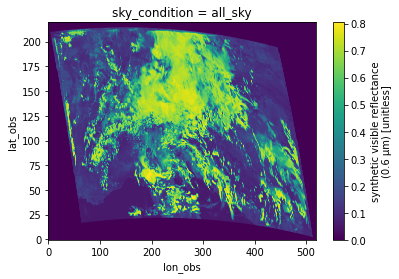

In [34]:
vis_all_sky.synthetic_reflectance_VIS006.plot()

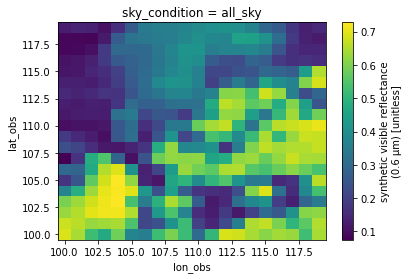

In [35]:
# Zoomed in bit with flat shading
vis_all_sky.synthetic_reflectance_VIS006[100:120,100:120].plot(shading='flat')

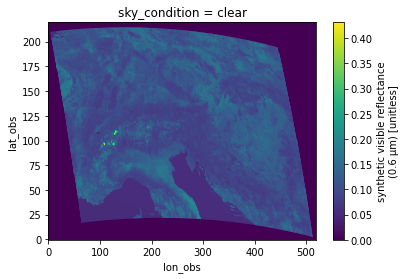

In [36]:
vis_clear_sky.synthetic_reflectance_VIS006.plot()

### Now for some more fancy plots with proper geografic projection and borders

In [37]:
def plot_2Dfield_AROME_basic(var,  lon, lat, cmap='turbo', vmin=None, vmax=None,mask_value=0.):
    """ 
       This should become the simplest function to plot a single 2D field with proper geografic borders and projecting. The Area of the AROME domain is hard coded, and needs to be adapted by hand if you wish to zoom in. 
       The function returns the figure, axes, and colorbar, which can then be customized before saving.
       
       inputs: 
       var       : 2D numpy array to be plotted
       lon, lat  : lon and lat values at center of gridpoints
       cmap      : colormap
       vmin,vmax : colorbar limits
       mask_value: Sets all values of var to 'nan' that have that value. Default is zero, as that is what sandy implemented for reflectances beyond the AROME model grid.
    
       output: figure, axes, and colorbar 
    """
    fig, axs = plt.subplots(1,1,figsize=(8, 5))
    
    # Mask out stuff that shouldn't be there, the default is 0 which sandy saves where there is no data
    var[var==mask_value]='nan'
    
    
    central_lon, central_lat = 13.8, 47.4
    m = Basemap(projection='lcc', lon_0=central_lon, lat_0=central_lat, llcrnrlon=central_lon - 9.1,  llcrnrlat=central_lat - 5.2, urcrnrlon=central_lon + 11.0, urcrnrlat=central_lat + 4.4, resolution='i')
    # map boundaries and coastlines
    m.drawcountries(ax = axs)
    m.drawcoastlines(ax = axs)
    
    # Convert lat/lon to map coordinates
    
    x, y = m(lon, lat)

    if vmin==None: vmin = np.nanmin(var) 
    if vmax==None: vmax = np.nanmax(var) 


    #Last thing to do is a bit of a dirty fix for the lats and lons being the center of the gridpoints, but pcolormesh needing the boxes around the middle points 
    #The corners of the boxes are linear interpolations and should be fine science wise. The edges are one a linear extrapolation. 
    nx, ny = x.shape
    x_ext = np.zeros([nx+1,ny+1])-10000000000000000000000000. # The high number is just to make it obsvious if something goes wrong
    y_ext = np.zeros([nx+1,ny+1])-10000000000000000000000000.
    x_ext[1:-1 ,1:-1] = x[1:,1:]/2.+x[:-1,:-1]/2 
    x_ext[0:-1 ,0   ] = 1.5*x[:,0]-0.5*x[:,1]
    x_ext[0:-1 ,-1  ] = 1.5*x[:,-1]-0.5*x[:,-2]
    x_ext[0    ,0:-1] = 1.5*x[0,:]-0.5*x[1,:]
    x_ext[-1   ,0:-1] = 1.5*x[-1,:]-0.5*x[-2,:]
    x_ext[-1,-1]      = 1.5*x_ext[-1,-2]-0.5*x_ext[-1,-3]
    y_ext[1:-1 ,1:-1] = y[1:,1:]/2.+y[:-1,:-1]/2 
    y_ext[0:-1 ,0   ] = 1.5*y[:,0]-0.5*y[:,1]
    y_ext[0:-1 ,-1  ] = 1.5*y[:,-1]-0.5*y[:,-2]
    y_ext[0    ,0:-1] = 1.5*y[0,:]-0.5*y[1,:]
    y_ext[-1   ,0:-1] = 1.5*y[-1,:]-0.5*y[-2,:]
    y_ext[-1,-1]      = 1.5*y_ext[-1,-2]-0.5*y_ext[-1,-3]


    # Plotting
    p1 = axs.pcolormesh(x_ext,y_ext,var, shading='flat', cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(p1, ax=axs, orientation='vertical', shrink=0.85,pad=0.01)
    
    # Draw latitude and longitude gridlines
    llcrnrlon = central_lon - 8.8
    urcrnrlon = central_lon + 10.8
    llcrnrlat = central_lat - 4.4
    urcrnrlat = central_lat + 3.4
    m.drawparallels(np.arange(llcrnrlat + 1, urcrnrlat, 3), labels=[1, 0, 0, 0.5],ax = axs)
    m.drawmeridians(np.arange(llcrnrlon + 1, urcrnrlon, 5), labels=[0, 0, 0, 1],ax = axs)

    return fig, axs, cbar

Deallocating this inst_id.
Atlas deallocated.
Atlas deallocated.


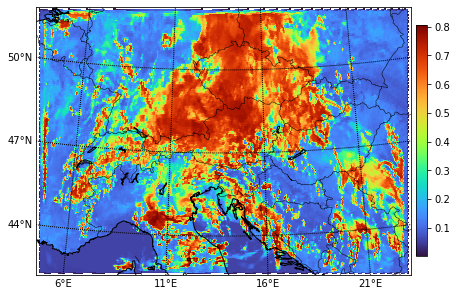

In [38]:
#Plotting using the defaults
fig, axs, cbar = plot_2Dfield_AROME_basic(vis_all_sky.synthetic_reflectance_VIS006[:,:].values,  vis_all_sky.lon_obs_map, vis_all_sky.lat_obs_map)

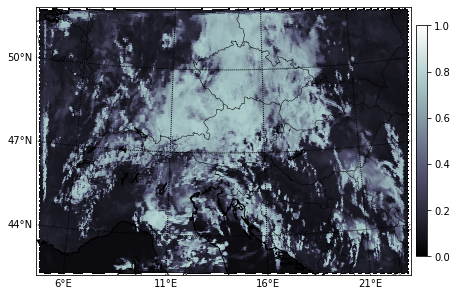

In [39]:
fig, axs, cbar = plot_2Dfield_AROME_basic(vis_all_sky.synthetic_reflectance_VIS006[:,:].values,  vis_all_sky.lon_obs_map, vis_all_sky.lat_obs_map, cmap='bone', vmin=0., vmax=1.)


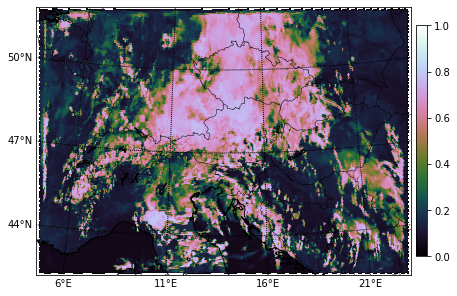

In [40]:
fig, axs, cbar = plot_2Dfield_AROME_basic(vis_all_sky.synthetic_reflectance_VIS006[:,:].values,  vis_all_sky.lon_obs_map, vis_all_sky.lat_obs_map, cmap='cubehelix', vmin=0., vmax=1.)


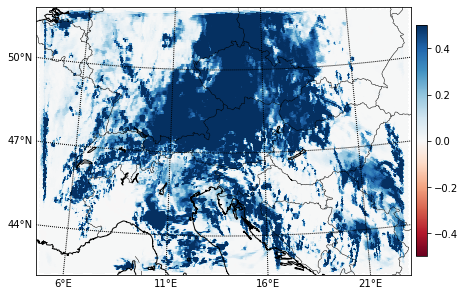

In [41]:
# Example showing the difference
fig, axs, cbar = plot_2Dfield_AROME_basic(vis_all_sky.synthetic_reflectance_VIS006[:,:].values-vis_clear_sky.synthetic_reflectance_VIS006[:,:].values,  
                                       vis_all_sky.lon_obs_map, vis_all_sky.lat_obs_map, cmap='RdBu', vmin=-0.5, vmax=0.5,mask_value=-10.) # setting a mask_value that doesn't exist


#### The plot can be modified afterwards and displayed again by typing fig

In this example I turned off the bounding box, and add a title to the axes and a label to the colorbar 


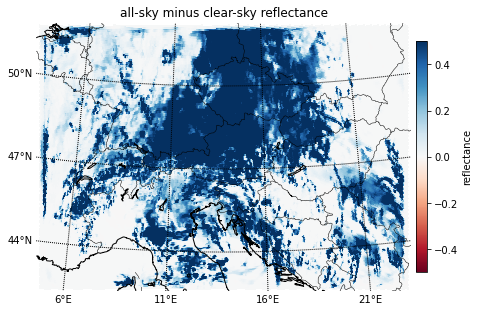

In [42]:
axs.set_title('all-sky minus clear-sky reflectance')
cbar.set_label('reflectance')
axs.axis('off')
fig